# Partie 2 - KPI et Analyse RH

Objectif : transformer les donnees brutes en indicateurs RH exploitables pour la decision, avec un angle turnover, engagement, carriere, remuneration et mobilite interne.


In [1]:
from pathlib import Path
import importlib
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "raw").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import hr_analysis_utils as utils
importlib.reload(utils)

MahalanobisAnomalyDetector = utils.MahalanobisAnomalyDetector
random_oversample_minority = utils.random_oversample_minority
SimpleLogisticRegression = utils.SimpleLogisticRegression
attrition_by_group = utils.attrition_by_group
attrition_gap_summary = utils.attrition_gap_summary
coefficient_importance = utils.coefficient_importance
correlation_with_attrition = utils.correlation_with_attrition
dataset_overview = utils.dataset_overview
kpi_table = utils.kpi_table
load_data = utils.load_data
missing_summary = utils.missing_summary
numeric_summary = utils.numeric_summary
plot_bar = utils.plot_bar
plot_box_by_attrition = utils.plot_box_by_attrition
plot_correlation_heatmap = utils.plot_correlation_heatmap
plot_histogram = utils.plot_histogram
plot_top_coefficients = utils.plot_top_coefficients
prepare_model_data = utils.prepare_model_data
prepare_numeric_anomaly_data = utils.prepare_numeric_anomaly_data
pr_auc_score_manual = utils.pr_auc_score_manual
roc_auc_score_manual = utils.roc_auc_score_manual
salary_gap_by_gender = utils.salary_gap_by_gender
average_by_group = utils.average_by_group
top_attrition_segments = utils.top_attrition_segments
find_best_threshold = utils.find_best_threshold
classification_metrics = utils.classification_metrics

DATA_PATH = PROJECT_ROOT / "raw" / "people_analytics_dataset.csv"
df = load_data(DATA_PATH)
pd.set_option("display.max_columns", 100)


## 1. Tableau de bord KPI


In [2]:
kpi_table(df)


,KPI,Valeur
0,Effectif total,8020.00
1,Taux d'attrition (%),18.80
2,Score d'engagement moyen,67.79
3,Score de securite psychologique moyen,53.72
4,Taux de promotion sur 3 ans (%),23.85
5,Taux de mobilite interne (%),61.91
6,Heures de formation moyennes,34.47
7,Absenteisme moyen (jours),13.88
8,Heures supp. moyennes,21.05
9,Salaire moyen annuel,62327.93


## 2. Turnover

Le turnover est desormais significatif. Il est utile de l'observer selon plusieurs segments RH pour faire ressortir les zones de vigilance et les priorites d'action.


In [3]:
display(attrition_by_group(df, "department"))
display(attrition_by_group(df, "country"))
display(attrition_by_group(df, "manager_level", ascending=True))
display(attrition_by_group(df, "salary_quartile", ascending=True))


,department,effectif,departs,attrition_rate_pct
3,HR,1036,223,21.53
2,Finance,950,196,20.63
7,Sales,1005,201,20.00
0,Customer Support,1027,195,18.99
1,Data,1042,188,18.04
4,IT,970,170,17.53
5,Marketing,972,170,17.49
6,Operations,1018,165,16.21


,country,effectif,departs,attrition_rate_pct
3,Spain,1281,257,20.06
1,France,1338,263,19.66
4,UK,1342,252,18.78
5,USA,1347,250,18.56
2,Germany,1356,244,17.99
0,Canada,1356,242,17.85


,manager_level,effectif,departs,attrition_rate_pct
1,1,1694,318,18.77
0,0,5258,988,18.79
2,2,816,154,18.87
3,3,252,48,19.05


C:\Users\quent\Documents\Cours\Master 2\People Analytics\Projet\hr_analysis_utils.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(group_col, dropna=False)


,salary_quartile,effectif,departs,attrition_rate_pct
3,Q4,2005,336,16.76
1,Q2,2086,385,18.46
2,Q3,1924,367,19.07
0,Q1,2005,420,20.95


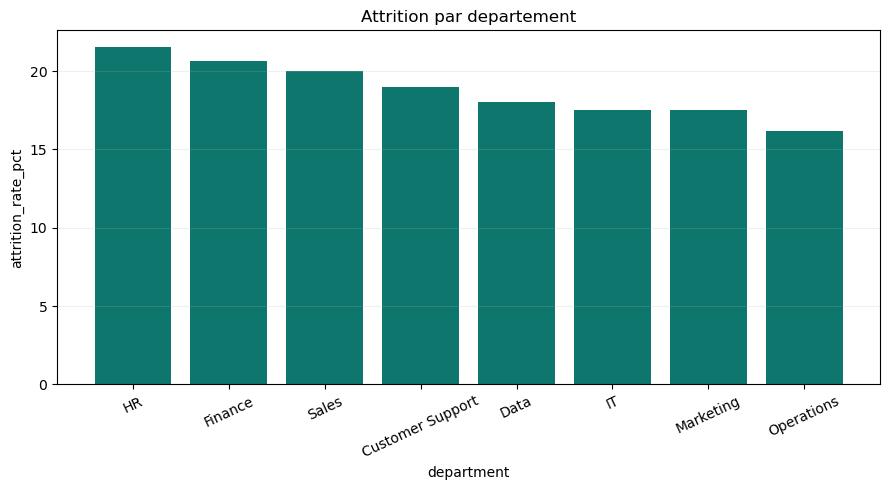

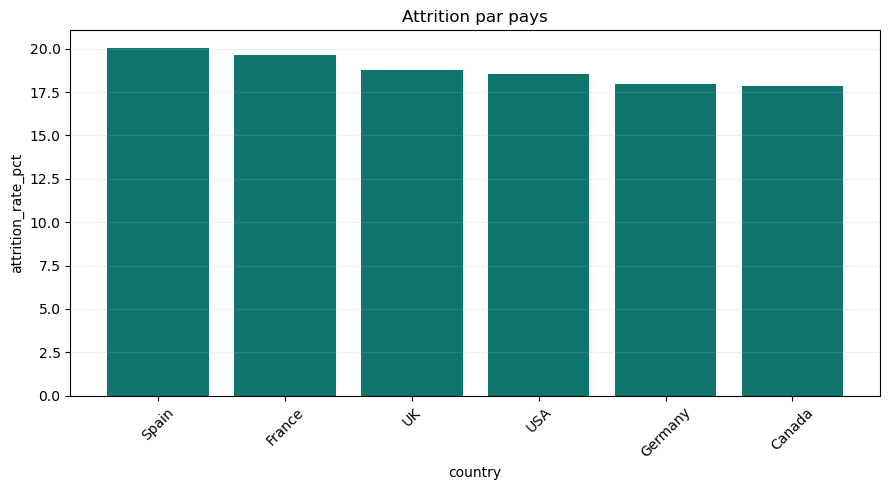

In [4]:
plot_bar(attrition_by_group(df, "department"), "department", "attrition_rate_pct", title="Attrition par departement", rotation=25)
plot_bar(attrition_by_group(df, "country"), "country", "attrition_rate_pct", title="Attrition par pays")


## 3. Engagement et conditions de travail

On relie ici l'engagement, la securite psychologique, l'absence et les heures supplementaires aux dynamiques de retention.


In [5]:
display(attrition_by_group(df, "engagement_band", ascending=True))
display(attrition_by_group(df, "overtime_band", ascending=True))
display(attrition_by_group(df, "absence_band", ascending=True))
display(average_by_group(df, "department", "engagement_score"))
display(average_by_group(df, "department", "psychological_safety_score"))


C:\Users\quent\Documents\Cours\Master 2\People Analytics\Projet\hr_analysis_utils.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(group_col, dropna=False)


,engagement_band,effectif,departs,attrition_rate_pct
3,Very High,1635,279,17.06
4,NaN,160,28,17.50
2,High,1831,321,17.53
1,Medium,2086,414,19.85
0,Low,2308,466,20.19


C:\Users\quent\Documents\Cours\Master 2\People Analytics\Projet\hr_analysis_utils.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(group_col, dropna=False)


,overtime_band,effectif,departs,attrition_rate_pct
0,0-5,848,123,14.50
1,6-15,1841,297,16.13
2,16-25,2503,449,17.94
3,26+,2828,639,22.60


C:\Users\quent\Documents\Cours\Master 2\People Analytics\Projet\hr_analysis_utils.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(group_col, dropna=False)


,absence_band,effectif,departs,attrition_rate_pct
1,3-5,987,18,1.82
0,0-2,236,7,2.97
2,6-10,1699,74,4.36
3,11+,5098,1409,27.64


,department,avg_engagement_score
0,HR,68.28
1,Data,68.02
2,Sales,68.02
3,Operations,67.91
4,Customer Support,67.73
5,Marketing,67.62
6,Finance,67.37
7,IT,67.32


,department,avg_psychological_safety_score
0,Finance,54.60
1,Data,53.96
2,IT,53.94
3,Marketing,53.71
4,Customer Support,53.67
5,Operations,53.65
6,Sales,53.24
7,HR,53.06


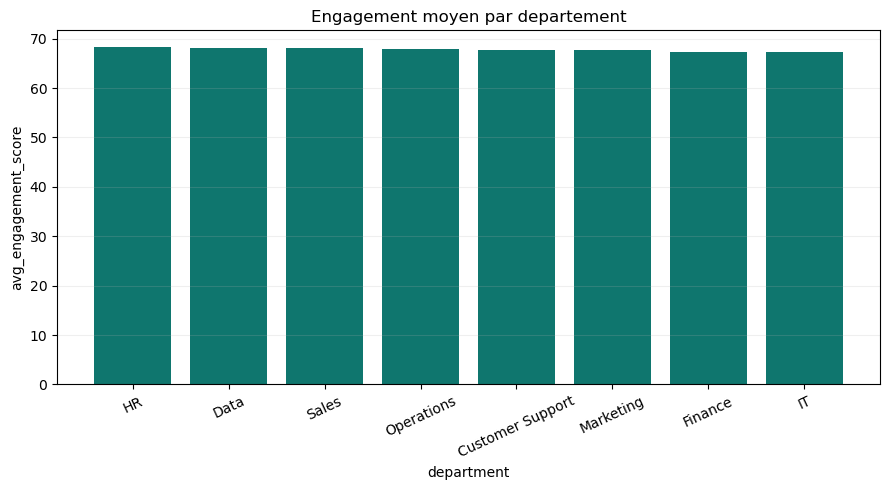

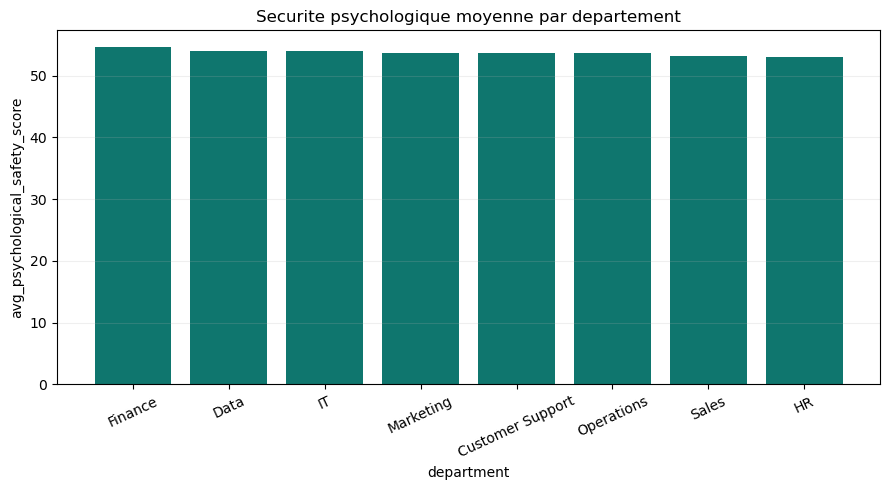

In [6]:
plot_bar(
    average_by_group(df, "department", "engagement_score"),
    "department",
    "avg_engagement_score",
    title="Engagement moyen par departement",
    rotation=25,
)
plot_bar(
    average_by_group(df, "department", "psychological_safety_score"),
    "department",
    "avg_psychological_safety_score",
    title="Securite psychologique moyenne par departement",
    rotation=25,
)


## 4. Evolution des carrieres


In [7]:
career_table = pd.DataFrame(
    {
        "promotion_rate_pct": df.groupby("department")["promotion_last_3y"].mean() * 100,
        "avg_training_hours": df.groupby("department")["training_hours"].mean(),
        "avg_internal_mobility": df.groupby("department")["internal_mobility_count"].mean(),
    }
).round(2).sort_values("promotion_rate_pct", ascending=False)

career_table


,promotion_rate_pct,avg_training_hours,avg_internal_mobility
department,,,
Data,25.62,34.60,1.01
HR,25.19,34.86,0.93
Operations,24.26,34.28,0.96
Finance,24.21,34.65,0.97
IT,23.81,34.63,1.00
Customer Support,23.17,33.89,0.97
Marketing,22.33,34.23,1.00
Sales,22.09,34.65,0.96


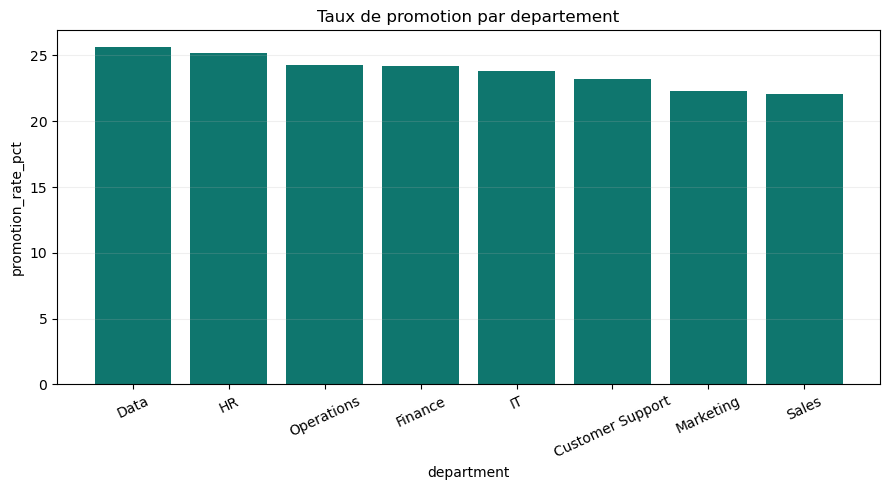

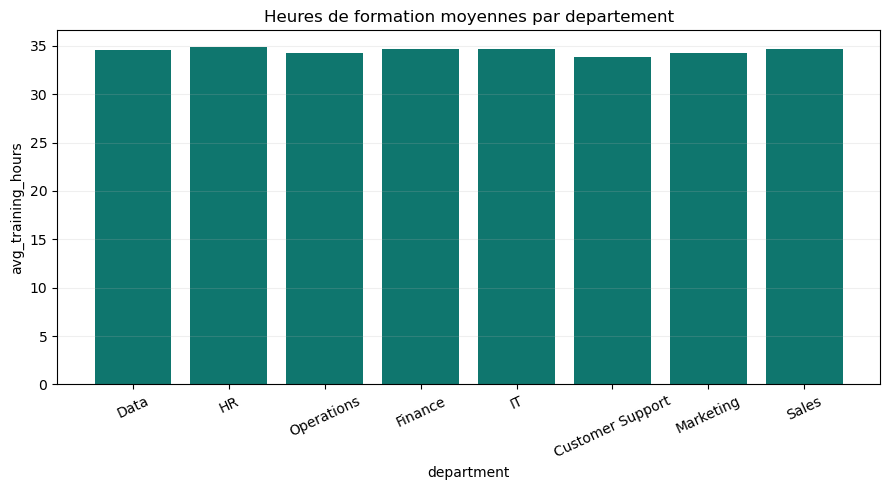

In [8]:
plot_bar(career_table.reset_index(), "department", "promotion_rate_pct", title="Taux de promotion par departement", rotation=25)
plot_bar(career_table.reset_index(), "department", "avg_training_hours", title="Heures de formation moyennes par departement", rotation=25)


## 5. Structure de remuneration

Cette partie permet d'ouvrir la discussion sur les niveaux de salaire, la progression par niveau hierarchique et les ecarts eventuels entre groupes.


In [9]:
salary_by_manager = average_by_group(df, "manager_level", "salary").sort_values("manager_level")
salary_by_manager


,manager_level,avg_salary
3,0,56242.23
2,1,68535.36
1,2,79532.19
0,3,91074.48


In [10]:
salary_gap_by_gender(df)


,gender,avg_salary,gap_vs_male_pct
0,Female,60924.52,-4.31
1,Male,63671.21,0.00
2,Non-Binary,63220.81,-0.71


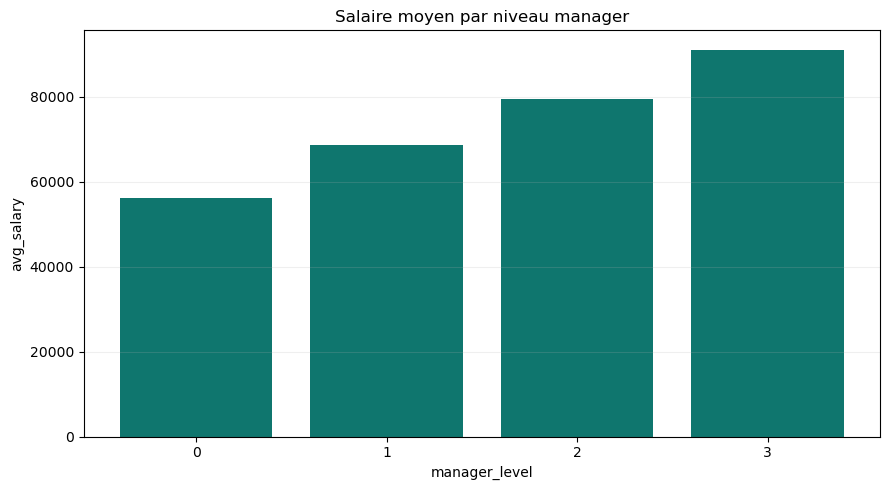

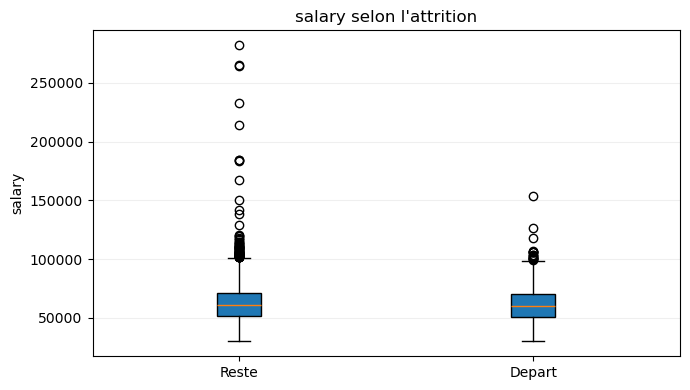

In [11]:
plot_bar(salary_by_manager, "manager_level", "avg_salary", title="Salaire moyen par niveau manager", rotation=0)
plot_box_by_attrition(df, "salary")


## 6. Mobilite interne


In [12]:
mobility_table = pd.DataFrame(
    {
        "mobility_rate_pct": df.groupby("department")["internal_mobility_count"].apply(lambda s: (s > 0).mean() * 100),
        "avg_internal_mobility": df.groupby("department")["internal_mobility_count"].mean(),
        "attrition_rate_pct": df.groupby("department")["attrition"].mean() * 100,
    }
).round(2).sort_values("mobility_rate_pct", ascending=False)

mobility_table


,mobility_rate_pct,avg_internal_mobility,attrition_rate_pct
department,,,
Data,63.34,1.01,18.04
IT,63.20,1.00,17.53
Marketing,62.86,1.00,17.49
Finance,62.21,0.97,20.63
Operations,61.59,0.96,16.21
Customer Support,61.54,0.97,18.99
Sales,61.19,0.96,20.00
HR,59.46,0.93,21.53


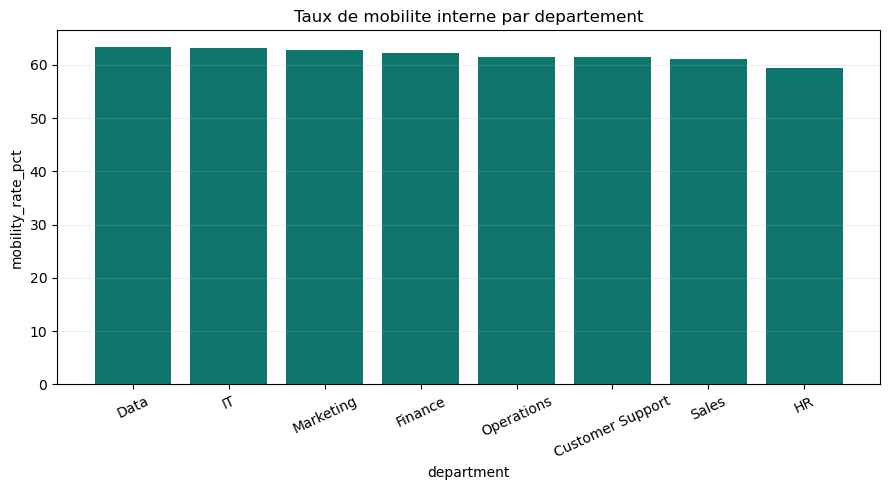

In [13]:
plot_bar(mobility_table.reset_index(), "department", "mobility_rate_pct", title="Taux de mobilite interne par departement", rotation=25)


## 7. Synthese analytique

- **Effectif** : 8 020 collaborateurs.
- **Attrition globale** : 18,80 %.
- **Engagement moyen** : 67,79 / 100.
- **Securite psychologique moyenne** : 53,72 / 100.
- **Promotion sur 3 ans** : 23,85 %.
- **Mobilite interne** : 61,91 % des collaborateurs ont connu au moins une mobilite.
- **Salaire moyen** : 62 328 par an.

### Points d'attention

- L'attrition est plus elevee en **Espagne**, en **France**, ainsi que dans les departements **HR**, **Finance** et **Sales**.
- Les collaborateurs avec **fort absentisme**, **heures supplementaires elevees** et **engagement plus faible** presentent davantage de risque de depart.
- Les collaborateurs partis ont en moyenne une **securite psychologique beaucoup plus basse**, **moins de mobilite interne**, **un salaire plus faible** et **moins d'anciennete**.
- Le salaire moyen des femmes ressort a un niveau inferieur a celui des hommes dans une lecture brute du dataset. Il faudrait prolonger par une analyse controlee des postes, pays et niveaux.
